#**Step 1: Setup & Data Loading for MNIST**
#Explanation
##This section sets the random seed for reproducibility, defines the data transformation for MNIST (grayscale images), loads the MNIST train and test datasets, combines them, and then splits the combined dataset into training (70%), validation (10%), and test (20%) splits. It also provides helper functions to display two sample images per class and to plot the class distribution.

100%|██████████| 9.91M/9.91M [00:10<00:00, 908kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 240kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.51MB/s]


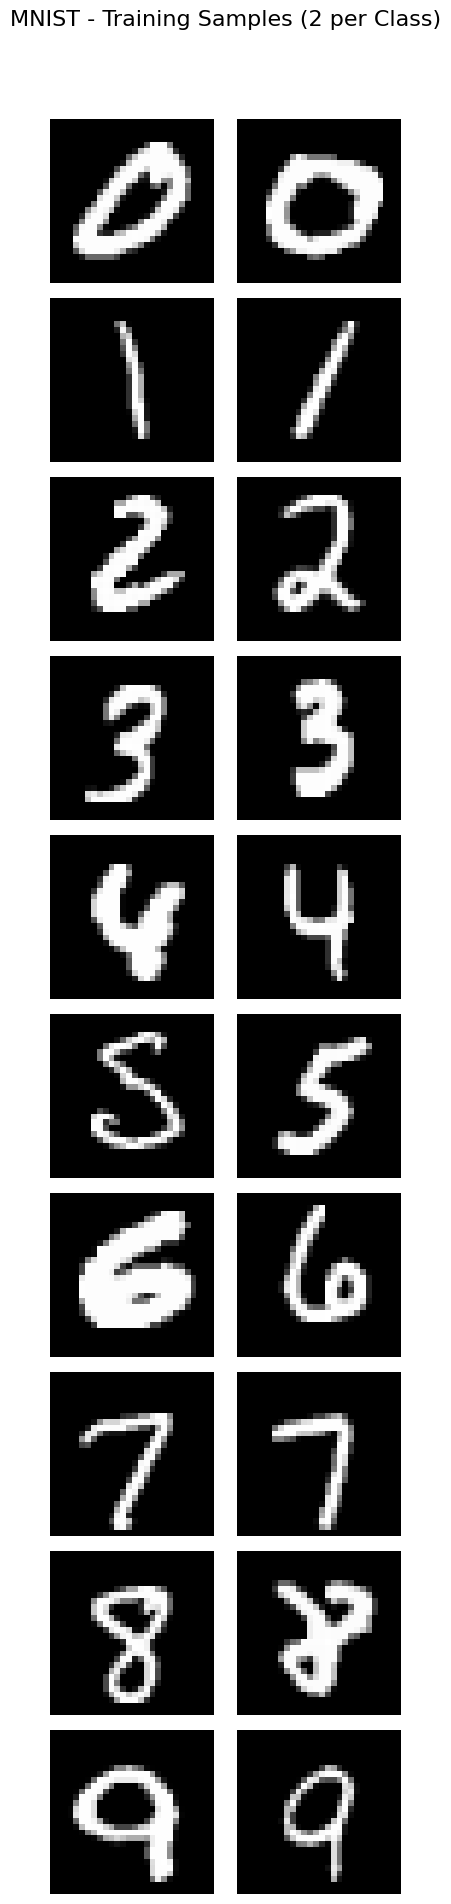

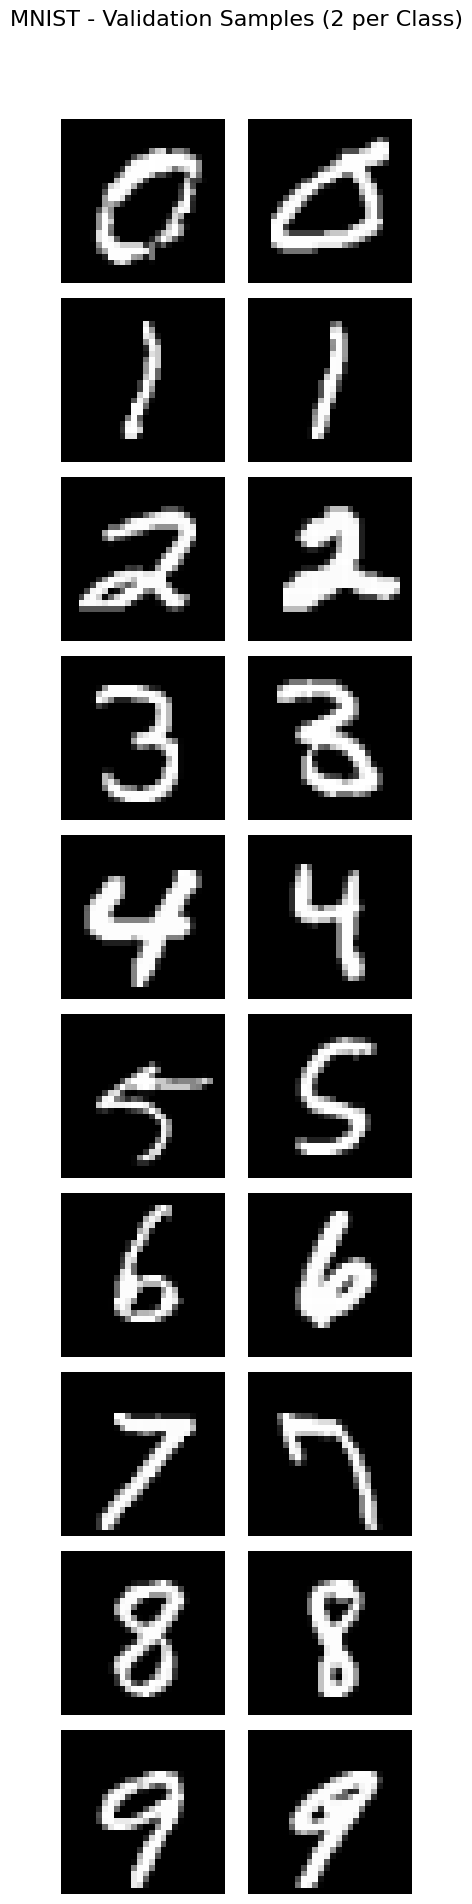

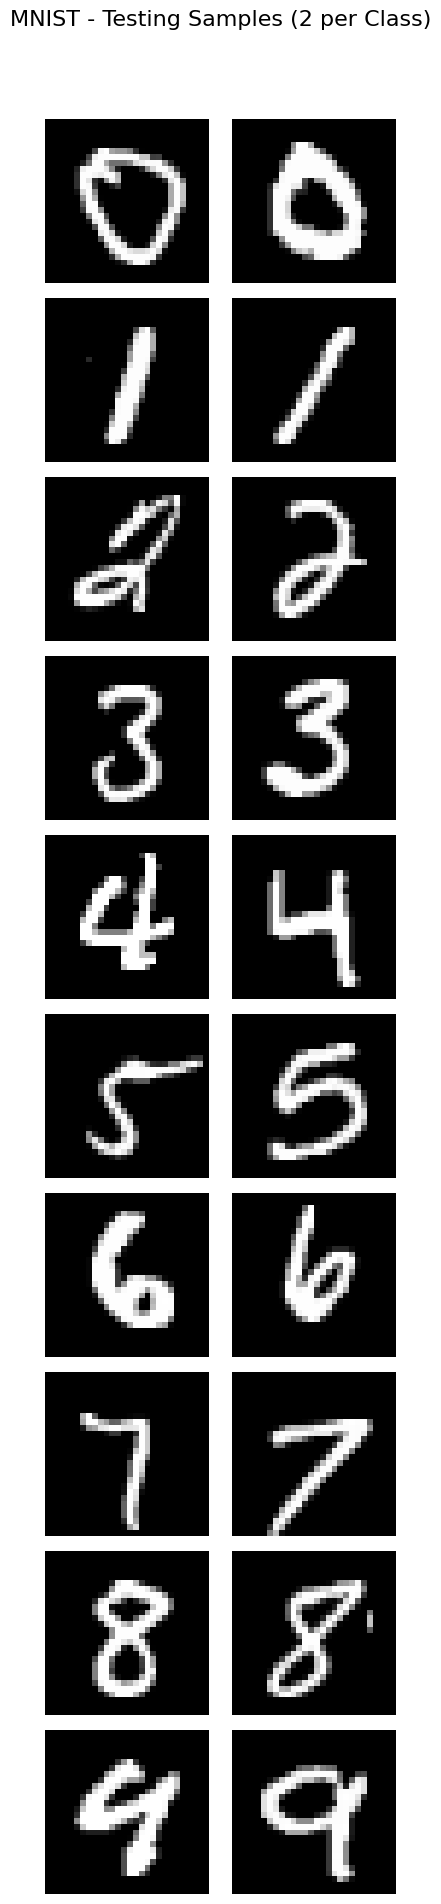

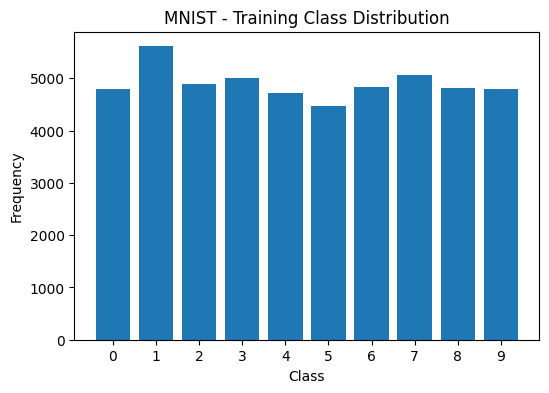

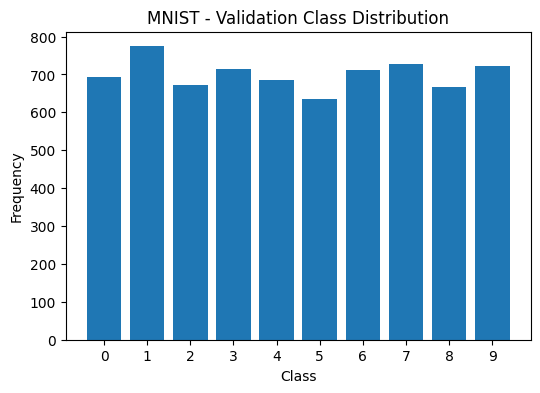

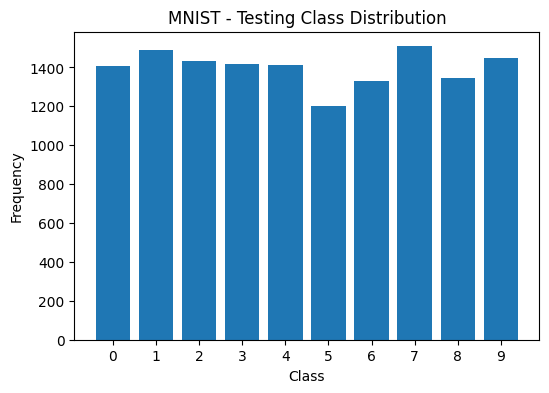

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset, random_split

# -------------------------------
# Set Seed for Reproducibility
# -------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# -------------------------------
# Define Data Transform for MNIST (grayscale images)
# -------------------------------
mnist_transform = transforms.ToTensor()

# -------------------------------
# Load and Combine MNIST Dataset
# -------------------------------
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)
mnist_full = ConcatDataset([mnist_train, mnist_test])

# -------------------------------
# Split Dataset into Train (70%), Val (10%), and Test (20%)
# -------------------------------
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2):
    total_len = len(dataset)
    train_len = int(train_ratio * total_len)
    val_len   = int(val_ratio * total_len)
    test_len  = total_len - train_len - val_len
    return random_split(dataset, [train_len, val_len, test_len])

mnist_train_split, mnist_val_split, mnist_test_split = split_dataset(mnist_full)

# -------------------------------
# Helper Functions for Plotting Samples & Distributions
# -------------------------------
def get_samples_per_class(dataset_split, num_samples=2):
    samples = {i: [] for i in range(10)}
    for img, label in dataset_split:
        if len(samples[label]) < num_samples:
            samples[label].append(img)
        # If we have collected enough samples for all classes, break early.
        if all(len(samples[c]) == num_samples for c in range(10)):
            break
    return samples

def plot_samples(samples, dataset_name, split_name):
    fig, axes = plt.subplots(10, 2, figsize=(4, 20))
    fig.suptitle(f'{dataset_name} - {split_name} Samples (2 per Class)', fontsize=16)
    for cls in range(10):
        for i in range(2):
            ax = axes[cls, i]
            img = samples[cls][i]
            ax.imshow(img.squeeze(), cmap='gray')
            ax.axis('off')
            if i == 0:
                ax.set_ylabel(f'Class {cls}', fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_distribution(dataset_split, dataset_name, split_name):
    counts = {i: 0 for i in range(10)}
    for _, label in dataset_split:
        counts[label] += 1
    classes = list(counts.keys())
    frequencies = list(counts.values())
    plt.figure(figsize=(6, 4))
    plt.bar(classes, frequencies, tick_label=classes)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.title(f'{dataset_name} - {split_name} Class Distribution')
    plt.show()

# -------------------------------
# Plot Sample Images and Class Distributions for Each Split
# -------------------------------
mnist_train_samples = get_samples_per_class(mnist_train_split)
mnist_val_samples   = get_samples_per_class(mnist_val_split)
mnist_test_samples  = get_samples_per_class(mnist_test_split)

plot_samples(mnist_train_samples, 'MNIST', 'Training')
plot_samples(mnist_val_samples, 'MNIST', 'Validation')
plot_samples(mnist_test_samples, 'MNIST', 'Testing')

plot_distribution(mnist_train_split, 'MNIST', 'Training')
plot_distribution(mnist_val_split, 'MNIST', 'Validation')
plot_distribution(mnist_test_split, 'MNIST', 'Testing')

# **Step 2: Define the CNN Model for MNIST**
#Explanation
##This section defines a simple convolutional neural network (CNN) designed for MNIST images (28×28, grayscale). The model includes two convolutional layers with batch normalization and ReLU activations, followed by max pooling layers and a fully connected layer that produces logits for 10 classes.

In [3]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, in_channels, img_size):
        """
        in_channels: Number of channels in the input image (1 for MNIST).
        img_size: Height/width of the square input image (28 for MNIST).
        """
        super(SimpleCNN, self).__init__()
        # First convolutional block: Conv -> BatchNorm -> ReLU -> MaxPool
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Second convolutional block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        # Calculate final feature map size after two pooling layers (divide by 4)
        final_size = img_size // 4
        # Fully connected layer for classification (10 classes)
        self.fc = nn.Linear(64 * final_size * final_size, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc(x)             # Output raw logits
        return x


#**Step 3: Define Training and Evaluation Functions**
#Explanation
##In this section, we define helper functions to:

##Train the model for one epoch.
##Evaluate the model (computing loss, accuracy, precision, and recall).
##Plot the training and validation curves.
##These functions will be used both during hyperparameter tuning and for final model training.

In [4]:
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall

def plot_training_curves(epochs_range, train_losses, val_losses, train_accs, val_accs, dataset_name):
    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label="Train Loss")
    plt.plot(epochs_range, val_losses, label="Validation Loss")
    plt.title(f"{dataset_name} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label="Train Accuracy")
    plt.plot(epochs_range, val_accs, label="Validation Accuracy")
    plt.title(f"{dataset_name} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

#**Step 4: Hyperparameter Tuning & Final Model Training for MNIST**
#Explanation
##In this section, we perform a grid search over multiple hyperparameters—including batch size, optimizer type, learning rate, and activation function—using an early stopping mechanism to select the best configuration based on the lowest validation loss. Once the best configuration is determined, we reinitialize and train a final model using these hyperparameters, then evaluate the model on the MNIST test set.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Tuning: Batch Size=64, Optimizer=Adam, LR=0.001, Activation=ReLU
Epoch 1/50 - Train Loss: 0.1262, Train Acc: 0.9619 | Val Loss: 0.1067, Val Acc: 0.9664
Epoch 2/50 - Train Loss: 0.0515, Train Acc: 0.9840 | Val Loss: 0.0576, Val Acc: 0.9836
Epoch 3/50 - Train Loss: 0.0382, Train Acc: 0.9878 | Val Loss: 0.0461, Val Acc: 0.9870
Epoch 4/50 - Train Loss: 0.0289, Train Acc: 0.9906 | Val Loss: 0.0497, Val Acc: 0.9851
Epoch 5/50 - Train Loss: 0.0247, Train Acc: 0.9921 | Val Loss: 0.0573, Val Acc: 0.9856
Epoch 6/50 - Train Loss: 0.0192, Train Acc: 0.9936 | Val Loss: 0.0459, Val Acc: 0.9894
Epoch 7/50 - Train Loss: 0.0153, Train Acc: 0.9950 | Val Loss: 0.0369, Val Acc: 0.9910
Epoch 8/50 - Train Loss: 0.0145, Train Acc: 0.9951 | Val Loss: 0.0500, Val Acc: 0.9877
Epoch 9/50 - Train Loss: 0.0102, Train Acc: 0.9964 | Val Loss: 0.0495, Val Acc: 0.9880
Epoch 10/50 - Train Loss: 0.0124, Train Acc: 0.9960 | Val Loss: 0.0534, Val Acc: 0.9867
Epoch 11/50 - Train Loss: 0.0079, Train Acc: 0.9975 | Val Loss:

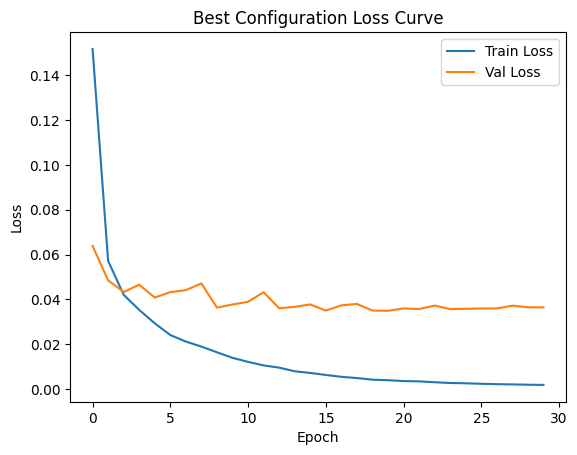

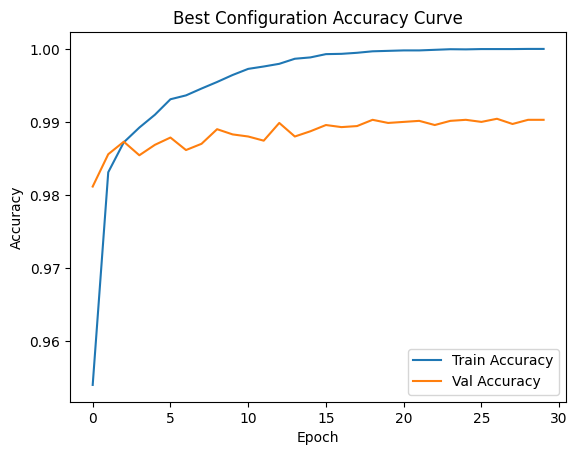


Training Final Model with Best Hyperparameters...
Epoch 1/50 - Train Loss: 0.1613, Train Acc: 0.9498 | Val Loss: 0.0637, Val Acc: 0.9799
Epoch 2/50 - Train Loss: 0.0594, Train Acc: 0.9820 | Val Loss: 0.0589, Val Acc: 0.9809
Epoch 3/50 - Train Loss: 0.0429, Train Acc: 0.9867 | Val Loss: 0.0632, Val Acc: 0.9809
Epoch 4/50 - Train Loss: 0.0348, Train Acc: 0.9894 | Val Loss: 0.0459, Val Acc: 0.9854
Epoch 5/50 - Train Loss: 0.0286, Train Acc: 0.9913 | Val Loss: 0.0430, Val Acc: 0.9869
Epoch 6/50 - Train Loss: 0.0243, Train Acc: 0.9929 | Val Loss: 0.0602, Val Acc: 0.9810
Epoch 7/50 - Train Loss: 0.0211, Train Acc: 0.9939 | Val Loss: 0.0385, Val Acc: 0.9891
Epoch 8/50 - Train Loss: 0.0173, Train Acc: 0.9952 | Val Loss: 0.0385, Val Acc: 0.9877
Epoch 9/50 - Train Loss: 0.0152, Train Acc: 0.9960 | Val Loss: 0.0377, Val Acc: 0.9897
Epoch 10/50 - Train Loss: 0.0134, Train Acc: 0.9968 | Val Loss: 0.0372, Val Acc: 0.9891
Epoch 11/50 - Train Loss: 0.0113, Train Acc: 0.9976 | Val Loss: 0.0418, Val Ac

In [7]:
import os
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Create directories for saving outputs (optional)
os.makedirs("output_plots", exist_ok=True)
os.makedirs("output_metrics", exist_ok=True)

# Define an improved CNN model with customizable activation function.
class SimpleCNN_Improved(nn.Module):
    def __init__(self, in_channels, img_size, activation=nn.ReLU()):
        """
        in_channels: Number of input channels (1 for MNIST)
        img_size: Height/width of input image (28 for MNIST)
        activation: Activation function to use (e.g., ReLU, LeakyReLU)
        """
        super(SimpleCNN_Improved, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        final_size = img_size // 4  # After two poolings (divide by 4)
        self.fc    = nn.Linear(64 * final_size * final_size, 10)

    def forward(self, x):
        x = self.pool(self.activation(self.bn1(self.conv1(x))))
        x = self.pool(self.activation(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Define the early stopping training function.
def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, epochs=50, patience=10):
    best_val_loss = float('inf')
    best_epoch = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_model_state = None

    for epoch in range(1, epochs+1):
        # Training phase
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = model.state_dict()
        elif epoch - best_epoch >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    return model, train_losses, train_accs, val_losses, val_accs, best_val_loss

# Define the hyperparameter grid.
optimizers_to_try = ["Adam", "SGD"]
learning_rates = [0.001, 0.005, 0.0005]
activations = {"ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU(0.1)}
batch_sizes = [64, 128]

best_config = None
best_val_loss_overall = float('inf')
best_tuning_results = None

results = []  # to store all tuning results

# Hyperparameter Tuning Loop
for bs in batch_sizes:
    # Create DataLoaders using current batch size.
    train_loader = DataLoader(mnist_train_split, batch_size=bs, shuffle=True)
    val_loader = DataLoader(mnist_val_split, batch_size=bs, shuffle=False)

    for opt_name in optimizers_to_try:
        for lr in learning_rates:
            for act_name, act_fn in activations.items():
                print(f"\nTuning: Batch Size={bs}, Optimizer={opt_name}, LR={lr}, Activation={act_name}")
                model = SimpleCNN_Improved(in_channels=1, img_size=28, activation=act_fn).to(device)
                if opt_name == "Adam":
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                elif opt_name == "SGD":
                    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
                criterion = torch.nn.CrossEntropyLoss()

                # Train with early stopping.
                trained_model, train_losses, train_accs, val_losses, val_accs, final_val_loss = train_with_early_stopping(
                    model, train_loader, val_loader, criterion, optimizer, device, epochs=50, patience=10
                )

                result = {
                    "batch_size": bs,
                    "optimizer": opt_name,
                    "learning_rate": lr,
                    "activation": act_name,
                    "val_loss": final_val_loss,
                    "val_accuracy": val_accs[-1]
                }
                results.append(result)

                if final_val_loss < best_val_loss_overall:
                    best_val_loss_overall = final_val_loss
                    best_config = result
                    best_tuning_results = {
                        "model_state": trained_model.state_dict(),
                        "train_losses": train_losses,
                        "train_accs": train_accs,
                        "val_losses": val_losses,
                        "val_accs": val_accs
                    }

print("\nBest Hyperparameter Configuration:")
print(best_config)

# Optionally, plot training curves for the best configuration.
plt.figure()
plt.plot(best_tuning_results["train_losses"], label="Train Loss")
plt.plot(best_tuning_results["val_losses"], label="Val Loss")
plt.title("Best Configuration Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(best_tuning_results["train_accs"], label="Train Accuracy")
plt.plot(best_tuning_results["val_accs"], label="Val Accuracy")
plt.title("Best Configuration Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -------------------------------------------------------------------
# Final Model Training Using the Best Hyperparameter Combination
# -------------------------------------------------------------------
# Use the best batch size from the tuning process.
best_bs = best_config["batch_size"]
final_train_loader = DataLoader(mnist_train_split, batch_size=best_bs, shuffle=True)
final_val_loader = DataLoader(mnist_val_split, batch_size=best_bs, shuffle=False)

# Instantiate a new model with the best activation function.
final_model = SimpleCNN_Improved(in_channels=1, img_size=28, activation=activations[best_config["activation"]]).to(device)
if best_config["optimizer"] == "Adam":
    final_optimizer = optim.Adam(final_model.parameters(), lr=best_config["learning_rate"])
elif best_config["optimizer"] == "SGD":
    final_optimizer = optim.SGD(final_model.parameters(), lr=best_config["learning_rate"], momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()

print("\nTraining Final Model with Best Hyperparameters...")
final_model, final_train_losses, final_train_accs, final_val_losses, final_val_accs, _ = train_with_early_stopping(
    final_model, final_train_loader, final_val_loader, criterion, final_optimizer, device, epochs=50, patience=10
)

# Evaluate final model on the MNIST test set.
final_test_loader = DataLoader(mnist_test_split, batch_size=best_bs, shuffle=False)
final_test_loss, final_test_acc, final_test_prec, final_test_rec = evaluate(final_model, final_test_loader, criterion, device)
print("\nFinal Model Test Metrics:")
print(f"Loss: {final_test_loss:.4f}, Accuracy: {final_test_acc:.4f}, Precision: {final_test_prec:.4f}, Recall: {final_test_rec:.4f}")

#**Step 5: Model Evaluation and Visualization for MNIST**
#Explanation
##In this step, we evaluate the final trained MNIST model on the test set. We:

##Visualize misclassified examples (up to two per class) so you can inspect where the model goes wrong.
##Display the softmax probability distributions for a few randomly chosen test samples.
##Plot a confusion matrix and print a classification report showing per-class performance.
##If you already ran the final model training (from the hyperparameter tuning section), this evaluation will use that model.

MNIST Misclassifications:


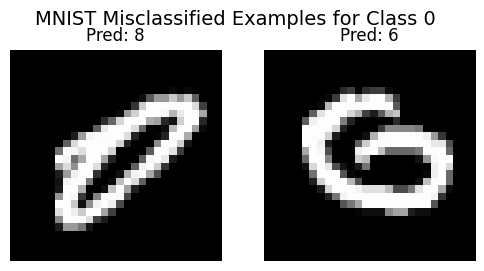

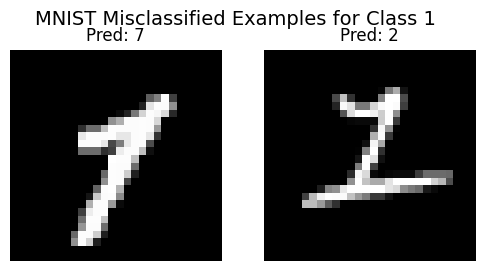

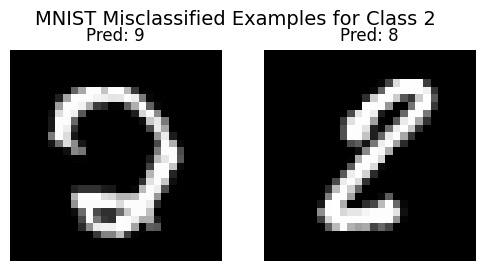

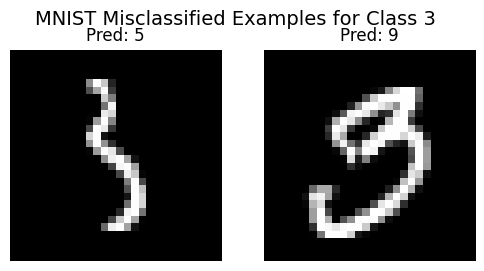

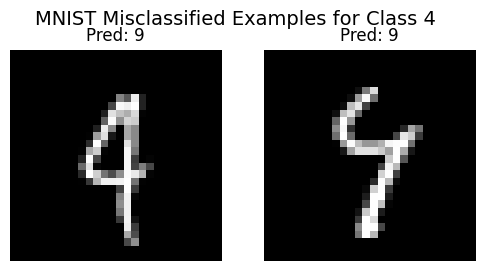

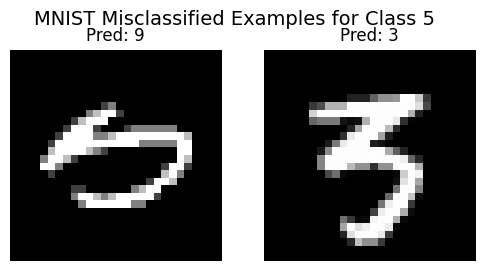

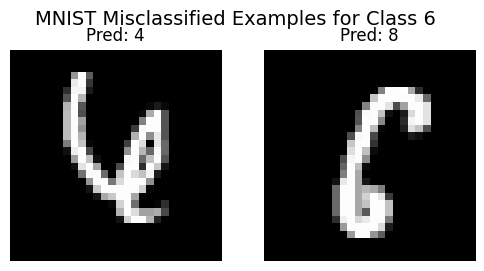

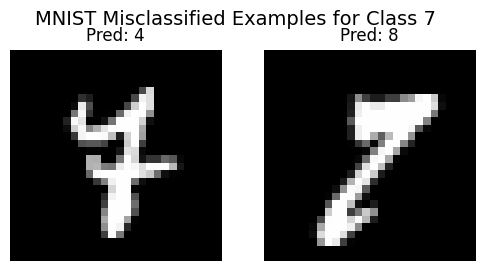

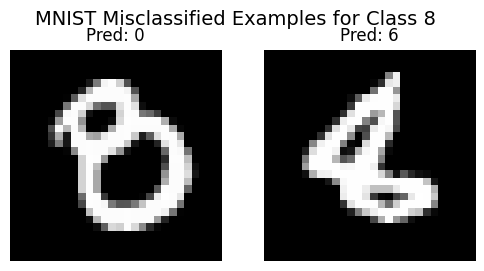

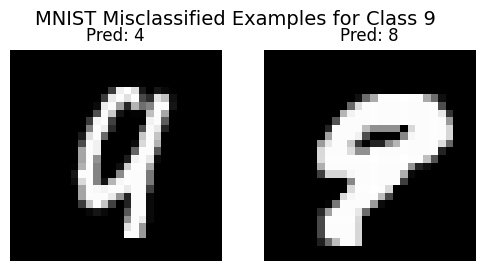


Inference and Visualization on MNIST:


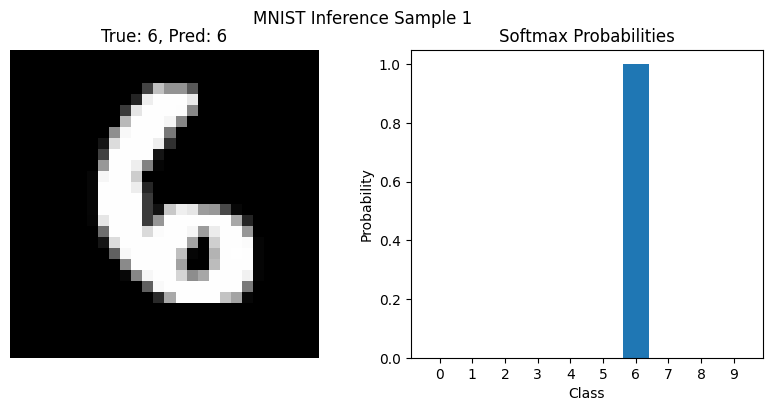

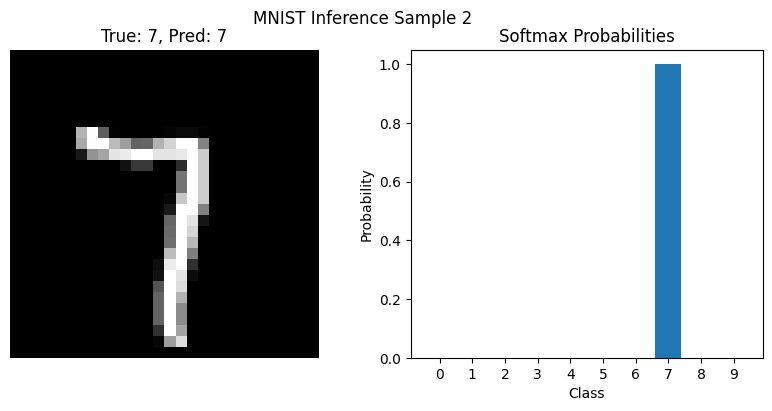

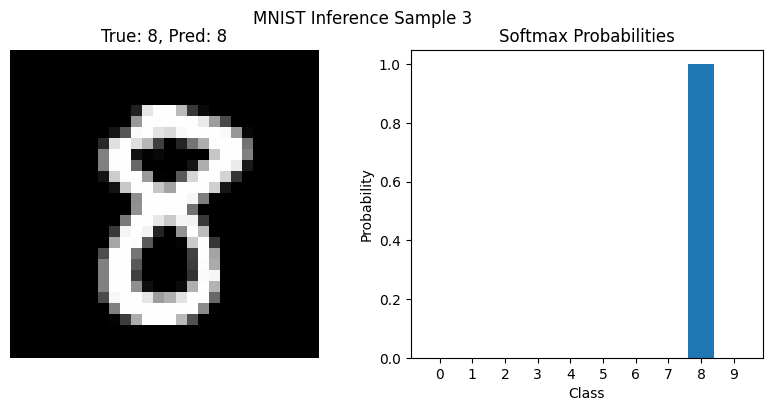

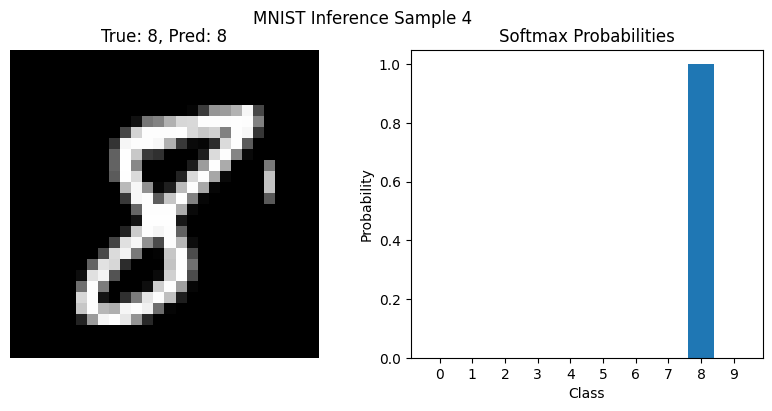

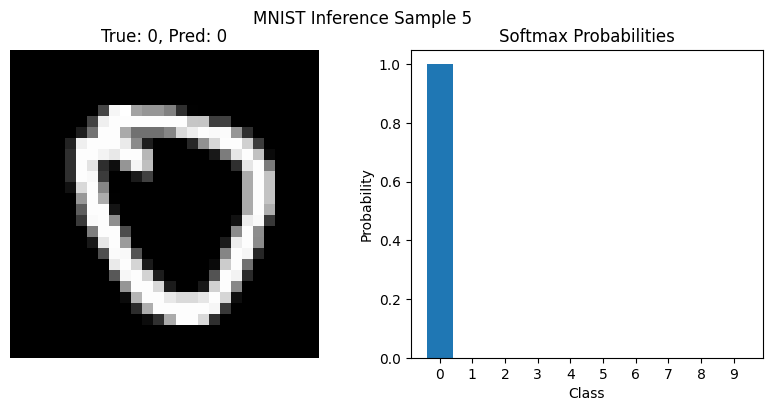

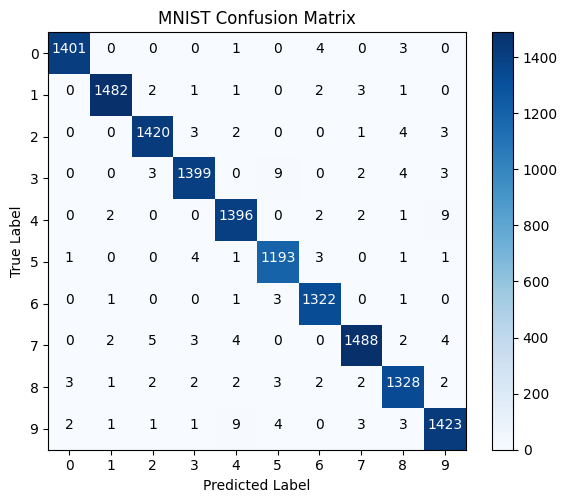

Classification Report for MNIST
              precision    recall  f1-score   support

           0     0.9957    0.9943    0.9950      1409
           1     0.9953    0.9933    0.9943      1492
           2     0.9909    0.9909    0.9909      1433
           3     0.9901    0.9852    0.9876      1420
           4     0.9852    0.9887    0.9869      1412
           5     0.9843    0.9909    0.9876      1204
           6     0.9903    0.9955    0.9929      1328
           7     0.9913    0.9867    0.9890      1508
           8     0.9852    0.9859    0.9855      1347
           9     0.9848    0.9834    0.9841      1447

    accuracy                         0.9894     14000
   macro avg     0.9893    0.9895    0.9894     14000
weighted avg     0.9894    0.9894    0.9894     14000



In [8]:
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report

def visualize_misclassifications(model, test_loader, device, dataset_name):
    model.eval()
    misclassified = {i: [] for i in range(10)}
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            for img, true_label, pred_label in zip(images, labels, preds):
                if true_label.item() != pred_label.item():
                    if len(misclassified[true_label.item()]) < 2:
                        misclassified[true_label.item()].append((img.cpu(), pred_label.item()))
            if all(len(misclassified[i]) >= 2 for i in range(10)):
                break

    for cls in range(10):
        examples = misclassified[cls]
        if examples:
            fig, axes = plt.subplots(1, len(examples), figsize=(3 * len(examples), 3))
            fig.suptitle(f'{dataset_name} Misclassified Examples for Class {cls}', fontsize=14)
            if len(examples) == 1:
                axes = [axes]
            for ax, (img, pred_label) in zip(axes, examples):
                ax.imshow(img.squeeze(), cmap='gray')
                ax.set_title(f"Pred: {pred_label}")
                ax.axis('off')
            plt.show()
        else:
            print(f"No misclassified examples found for class {cls} in {dataset_name}.")

def inference_and_visualization(model, test_loader, device, dataset_name, num_samples=5):
    model.eval()
    softmax = torch.nn.Softmax(dim=1)
    images_list = []
    true_labels_list = []
    preds_list = []
    probs_list = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = softmax(outputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            for i in range(images.size(0)):
                if len(images_list) < num_samples:
                    images_list.append(images[i].cpu())
                    true_labels_list.append(labels[i].cpu().item())
                    preds_list.append(preds[i].cpu().item())
                    probs_list.append(probabilities[i].cpu().numpy())
    for i in range(num_samples):
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(images_list[i].squeeze(), cmap='gray')
        axes[0].set_title(f"True: {true_labels_list[i]}, Pred: {preds_list[i]}")
        axes[0].axis('off')
        axes[1].bar(range(10), probs_list[i])
        axes[1].set_xticks(range(10))
        axes[1].set_xlabel("Class")
        axes[1].set_ylabel("Probability")
        axes[1].set_title("Softmax Probabilities")
        plt.suptitle(f"{dataset_name} Inference Sample {i+1}")
        plt.show()

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

    print("Classification Report for", dataset_name)
    print(classification_report(all_labels, all_preds, digits=4))

# Evaluate the final model on the MNIST test set.
print("MNIST Misclassifications:")
visualize_misclassifications(final_model, final_test_loader, device, "MNIST")

print("\nInference and Visualization on MNIST:")
inference_and_visualization(final_model, final_test_loader, device, "MNIST")

# **Step 6: Cross-Dataset Evaluation – Using the MNIST-Trained Model on SVHN Test Data**

## Explanation

### Data Preparation

- **Transformation:** Since the MNIST model is trained on 28×28 grayscale images, we convert SVHN’s RGB images to grayscale and resize them to 28×28.
- **SVHN Test Set Loading:** The SVHN test dataset is loaded using the above transformation to ensure compatibility with the MNIST-trained model.

### Evaluation

- **Metrics Calculation:** A helper function (`evaluate_cross_dataset`) computes the loss, accuracy, precision, and recall on the SVHN test set using the MNIST model.
- **Classification Report:** The function also returns predictions and true labels to print a detailed classification report.

### Visualization

- **Misclassified Examples:** The function `visualize_misclassifications_cross` gathers and displays up to two misclassified samples per class from the SVHN test set.
- **UMAP Embedding:** The features from the model’s fully connected layer (output logits) are extracted from the SVHN test set. UMAP is then applied to reduce these features to 2D for visualization of the latent space.
- **Scatter Plot:** The resulting 2D UMAP embedding is plotted with points colored by their true class labels.


100%|██████████| 64.3M/64.3M [00:15<00:00, 4.14MB/s]



Cross-Dataset Evaluation (MNIST Model on SVHN Test Set):
Loss: 4.4792, Accuracy: 0.0715, Precision: 0.5638, Recall: 0.1066

SVHN Misclassifications (Cross-Dataset Evaluation):


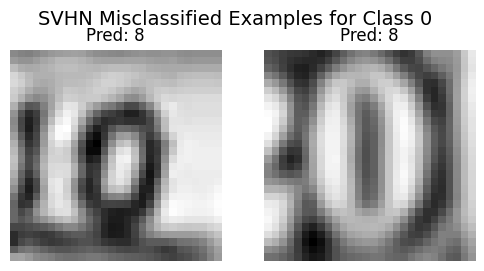

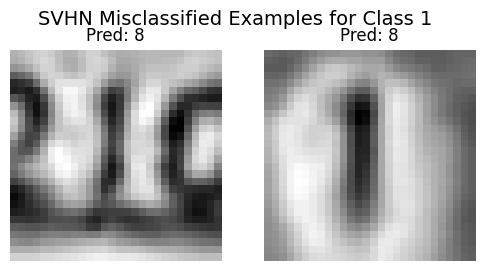

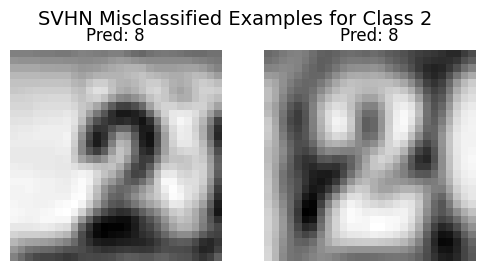

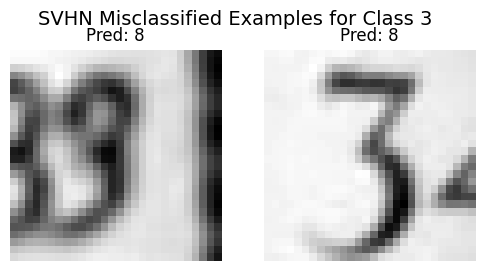

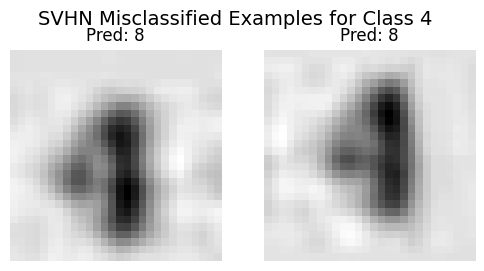

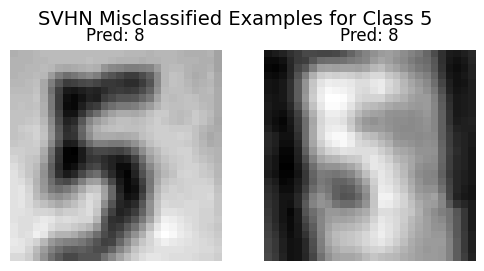

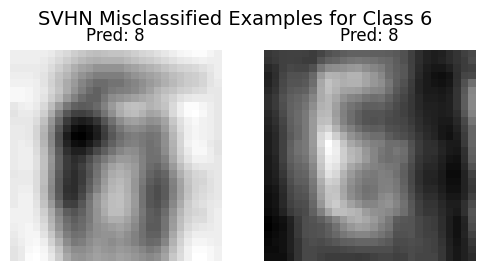

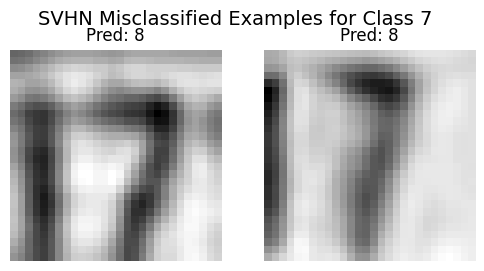

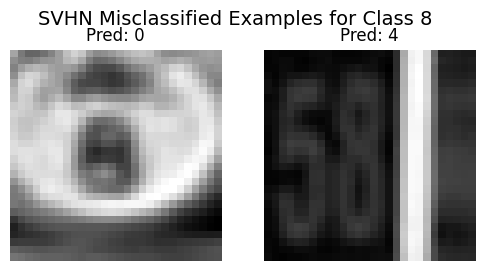

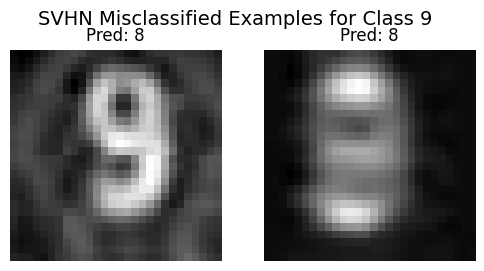

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


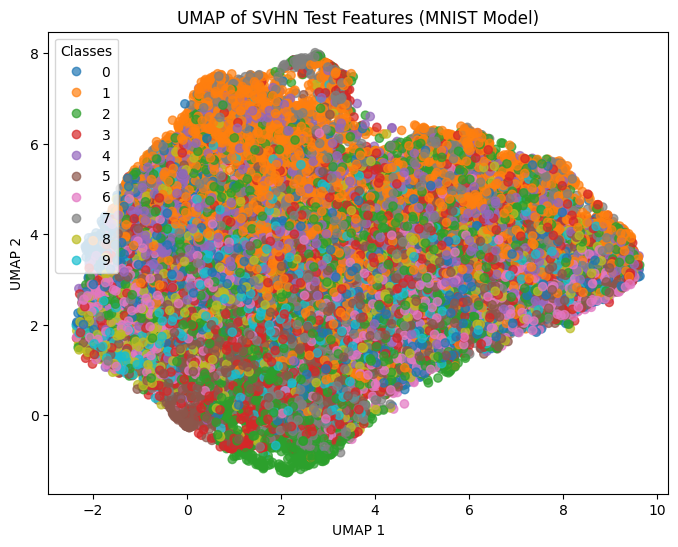

Classification Report for SVHN (Cross-Dataset Evaluation):
              precision    recall  f1-score   support

           0     0.3759    0.0287    0.0533      1744
           1     0.6786    0.0186    0.0363      5099
           2     0.6923    0.0065    0.0129      4149
           3     1.0000    0.0024    0.0048      2882
           4     0.2453    0.0052    0.0101      2523
           5     1.0000    0.0004    0.0008      2384
           6     0.3636    0.0020    0.0040      1977
           7     1.0000    0.0025    0.0049      2019
           8     0.0646    0.9970    0.1213      1660
           9     0.2174    0.0031    0.0062      1595

    accuracy                         0.0715     26032
   macro avg     0.5638    0.1066    0.0255     26032
weighted avg     0.6171    0.0715    0.0231     26032



In [11]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

# -------------------------------
# Data Preparation for SVHN
# -------------------------------
# Define a transform for SVHN that converts images to grayscale and resizes them to 28x28.
svhn_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert RGB to grayscale
    transforms.Resize((28, 28)),                  # Resize to 28x28 to match MNIST
    transforms.ToTensor()                         # Convert to tensor
])

# Load the SVHN test dataset with the new transform.
svhn_test = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=svhn_transform)
svhn_test_loader = DataLoader(svhn_test, batch_size=64, shuffle=False)

# -------------------------------
# Evaluation on SVHN using the MNIST-Trained Model
# -------------------------------
def evaluate_cross_dataset(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, all_preds, all_labels

criterion = torch.nn.CrossEntropyLoss()
svhn_loss, svhn_acc, svhn_prec, svhn_rec, svhn_preds, svhn_labels = evaluate_cross_dataset(final_model, svhn_test_loader, criterion, device)

print("\nCross-Dataset Evaluation (MNIST Model on SVHN Test Set):")
print(f"Loss: {svhn_loss:.4f}, Accuracy: {svhn_acc:.4f}, Precision: {svhn_prec:.4f}, Recall: {svhn_rec:.4f}")

# -------------------------------
# Misclassification Visualization for SVHN
# -------------------------------
def visualize_misclassifications_cross(model, dataloader, device, dataset_name):
    model.eval()
    misclassified = {}
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            for img, true_label, pred_label in zip(images, labels, preds):
                if true_label.item() != pred_label.item():
                    if true_label.item() not in misclassified:
                        misclassified[true_label.item()] = []
                    if len(misclassified[true_label.item()]) < 2:
                        misclassified[true_label.item()].append((img.cpu(), pred_label.item()))
            # If we've collected misclassified examples for all classes, break early.
            if len(misclassified) == 10 and all(len(misclassified[c]) >= 2 for c in misclassified):
                break

    for cls in sorted(misclassified.keys()):
        examples = misclassified[cls]
        if examples:
            fig, axes = plt.subplots(1, len(examples), figsize=(3 * len(examples), 3))
            fig.suptitle(f'{dataset_name} Misclassified Examples for Class {cls}', fontsize=14)
            if len(examples) == 1:
                axes = [axes]
            for ax, (img, pred_label) in zip(axes, examples):
                ax.imshow(img.squeeze(), cmap='gray')
                ax.set_title(f"Pred: {pred_label}")
                ax.axis('off')
            plt.show()
        else:
            print(f"No misclassified examples found for class {cls} in {dataset_name}.")

print("\nSVHN Misclassifications (Cross-Dataset Evaluation):")
visualize_misclassifications_cross(final_model, svhn_test_loader, device, "SVHN")

# -------------------------------
# UMAP Visualization of SVHN Features (Cross-Dataset)
# -------------------------------
def extract_features_cross(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

svhn_features, svhn_labels = extract_features_cross(final_model, svhn_test_loader, device)

umap_reducer = umap.UMAP(n_components=2, random_state=42)
svhn_embedded = umap_reducer.fit_transform(svhn_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(svhn_embedded[:, 0], svhn_embedded[:, 1], c=svhn_labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("UMAP of SVHN Test Features (MNIST Model)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# -------------------------------
# Classification Report for SVHN (Cross-Dataset)
# -------------------------------
print("Classification Report for SVHN (Cross-Dataset Evaluation):")
print(classification_report(svhn_labels, svhn_preds, digits=4))

#**Step 7: UMAP Dimensionality Reduction for MNIST Features**
#Explanation
##Here we extract the feature representations (the output from the fully connected layer) from the trained MNIST model on the test set. We then apply UMAP to reduce these features to 2 dimensions for visualization. The resulting scatter plot shows clusters of digits based on the model’s learned representations.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


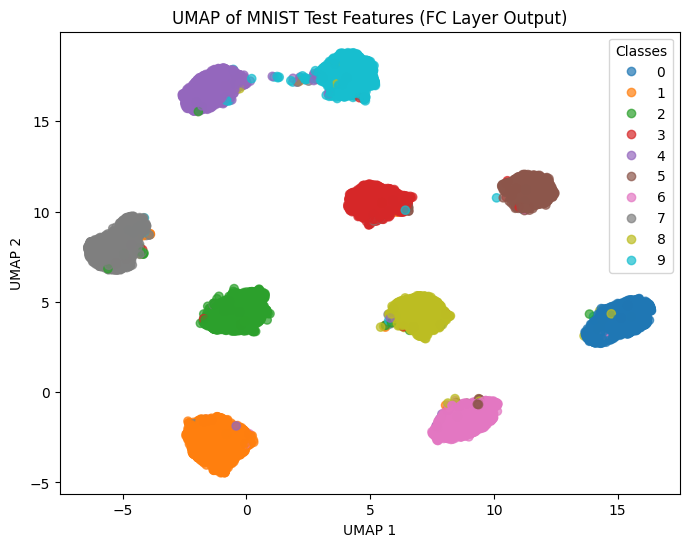

In [9]:
!pip install umap-learn -q

import umap

def extract_features(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

# Extract features from the MNIST test set.
mnist_features, mnist_labels = extract_features(final_model, final_test_loader, device)

# Apply UMAP for dimensionality reduction.
umap_reducer = umap.UMAP(n_components=2, random_state=42)
mnist_embedded = umap_reducer.fit_transform(mnist_features)

# Plot the UMAP embedding.
plt.figure(figsize=(8,6))
scatter = plt.scatter(mnist_embedded[:, 0], mnist_embedded[:, 1], c=mnist_labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("UMAP of MNIST Test Features (FC Layer Output)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# **Step 8: Imbalanced Training & Analysis on MNIST (Classes 1 and 2)**

## Explanation

In this section, we simulate imbalanced training by focusing on only two classes (1 and 2) from MNIST. We perform the following steps for each imbalance scenario:

### Imbalance Scenarios

- **Case 1:** Use 50 samples of class 1 and 1000 samples of class 2.
- **Case 2:** Use 500 samples of class 1 and 1000 samples of class 2.
- **Case 3:** Use all available samples for classes 1 and 2.

### For Each Case

1. **Data Filtering:**
   - Filter the MNIST training set to only include classes 1 and 2.
   - Sample the desired number of examples per class.
2. **Model Training:**
   - Train a CNN model for 50 epochs on this imbalanced data.
3. **Evaluation:**
   - Filter the MNIST test set to only include classes 1 and 2.
   - Evaluate the model on the filtered test set and record metrics.
4. **Feature Extraction and Visualization:**
   - Extract features from the final fully connected layer.
   - Use UMAP to visualize the latent space.

This analysis helps us understand how class imbalance affects model performance and the structure of the learned representations.



Training MNIST Model - Case 1
Epoch 1/50 - Train Loss: 0.1747, Train Acc: 0.9286
Epoch 10/50 - Train Loss: 0.0007, Train Acc: 1.0000
Epoch 20/50 - Train Loss: 0.0002, Train Acc: 1.0000
Epoch 30/50 - Train Loss: 0.0001, Train Acc: 1.0000
Epoch 40/50 - Train Loss: 0.0001, Train Acc: 1.0000
Epoch 50/50 - Train Loss: 0.0000, Train Acc: 1.0000
MNIST Test Metrics (Classes 1 & 2): Loss: 0.0573, Acc: 0.9887, Prec: 0.9887, Rec: 0.9889


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


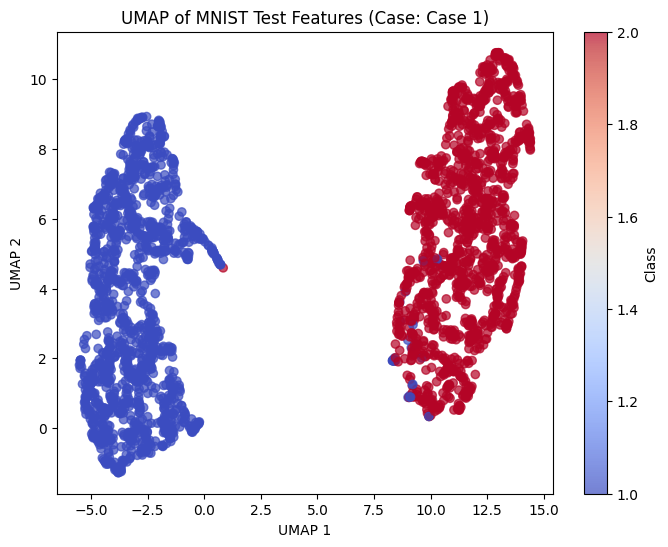


Training MNIST Model - Case 2
Epoch 1/50 - Train Loss: 0.1630, Train Acc: 0.9387
Epoch 10/50 - Train Loss: 0.0019, Train Acc: 1.0000
Epoch 20/50 - Train Loss: 0.0005, Train Acc: 1.0000
Epoch 30/50 - Train Loss: 0.0002, Train Acc: 1.0000
Epoch 40/50 - Train Loss: 0.0001, Train Acc: 1.0000
Epoch 50/50 - Train Loss: 0.0001, Train Acc: 1.0000
MNIST Test Metrics (Classes 1 & 2): Loss: 0.0133, Acc: 0.9973, Prec: 0.9973, Rec: 0.9973


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


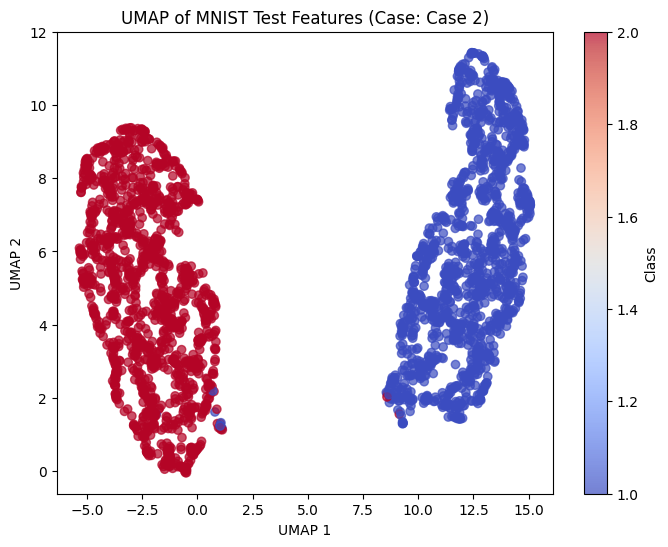


Training MNIST Model - Case 3
Epoch 1/50 - Train Loss: 0.0449, Train Acc: 0.9836
Epoch 10/50 - Train Loss: 0.0002, Train Acc: 1.0000
Epoch 20/50 - Train Loss: 0.0030, Train Acc: 0.9989
Epoch 30/50 - Train Loss: 0.0000, Train Acc: 1.0000
Epoch 40/50 - Train Loss: 0.0000, Train Acc: 1.0000
Epoch 50/50 - Train Loss: 0.0000, Train Acc: 1.0000
MNIST Test Metrics (Classes 1 & 2): Loss: 0.0060, Acc: 0.9986, Prec: 0.9986, Rec: 0.9986


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


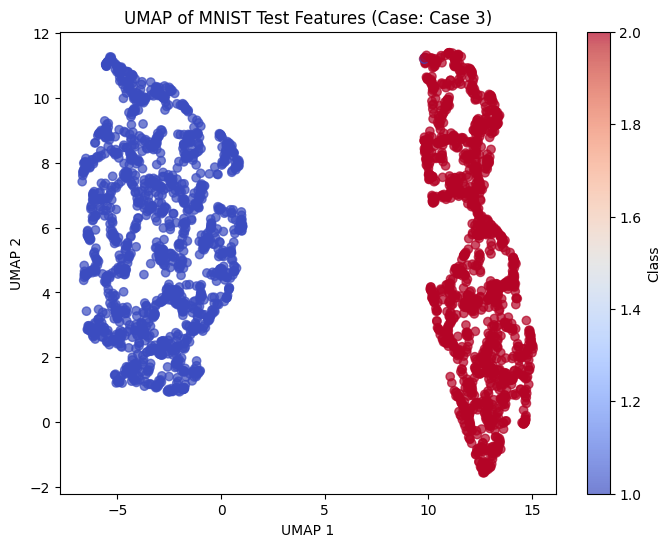


Summary of MNIST Imbalanced Training Results (Classes 1 & 2):
Case 1: {'loss': 0.05726609478585231, 'accuracy': 0.9887179487179487, 'precision': 0.9887288069029746, 'recall': 0.9889272210570823}
Case 2: {'loss': 0.013345170193232406, 'accuracy': 0.9972649572649572, 'precision': 0.9972511283118584, 'recall': 0.9972776417235257}
Case 3: {'loss': 0.005995724263894436, 'accuracy': 0.9986324786324786, 'precision': 0.9986465779259596, 'recall': 0.9986181242972523}

Analysis:
- In Case 1 (severe imbalance), the model may underfit the minority class (1), leading to lower performance and less distinct latent clusters.
- Case 2 shows improved balance with better performance compared to Case 1.
- Case 3 (using all available data) typically yields the best performance and well-separated clusters in the UMAP visualization.


In [12]:
from torch.utils.data import Dataset

# Helper function to filter a dataset for allowed classes.
def filter_dataset(dataset, allowed_classes):
    filtered = []
    for img, label in dataset:
        if label in allowed_classes:
            filtered.append((img, label))
    return filtered

# Helper function to sample a fixed number of samples per class.
def sample_imbalanced(data, sample_counts):
    data_by_class = {cls: [] for cls in sample_counts.keys()}
    for item in data:
        img, label = item
        if label in data_by_class:
            data_by_class[label].append(item)
    sampled_data = []
    for cls, count in sample_counts.items():
        class_items = data_by_class[cls]
        random.shuffle(class_items)
        sampled_data.extend(class_items[:count])
    random.shuffle(sampled_data)
    return sampled_data

# Create a custom dataset wrapper.
class CustomDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Filter MNIST training and test splits for classes 1 and 2.
mnist_train_filtered = filter_dataset(mnist_train_split, [1, 2])
mnist_test_filtered = filter_dataset(mnist_test_split, [1, 2])

# Create DataLoader for the MNIST test set (classes 1 and 2).
mnist_test_loader_12 = DataLoader(CustomDataset(mnist_test_filtered), batch_size=64, shuffle=False)

# Define hyperparameters for imbalanced training.
imbalanced_cases = {
    "Case 1": {1: 50, 2: 1000},
    "Case 2": {1: 500, 2: 1000},
    "Case 3": "Full"  # Use all available samples for classes 1 and 2.
}
epochs_imbalanced = 50
learning_rate_imbalanced = 0.001
criterion = torch.nn.CrossEntropyLoss()

results_mnist_imbalanced = {}

for case, counts in imbalanced_cases.items():
    print(f"\n{'='*20}\nTraining MNIST Model - {case}\n{'='*20}")
    if counts == "Full":
        imbalanced_train_data = mnist_train_filtered
    else:
        imbalanced_train_data = sample_imbalanced(mnist_train_filtered, counts)
    train_loader = DataLoader(CustomDataset(imbalanced_train_data), batch_size=64, shuffle=True)

    # Initialize a fresh model (using SimpleCNN_Improved with default ReLU).
    model_imbalanced = SimpleCNN_Improved(in_channels=1, img_size=28, activation=nn.ReLU()).to(device)
    optimizer_imbalanced = optim.Adam(model_imbalanced.parameters(), lr=learning_rate_imbalanced)

    # Train for 50 epochs.
    for epoch in range(1, epochs_imbalanced+1):
        train_loss, train_acc = train_epoch(model_imbalanced, train_loader, optimizer_imbalanced, criterion, device)
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs_imbalanced} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

    # Evaluate on MNIST test set (classes 1 and 2).
    test_loss, test_acc, test_prec, test_rec = evaluate(model_imbalanced, mnist_test_loader_12, criterion, device)[:4]
    print(f"MNIST Test Metrics (Classes 1 & 2): Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}")

    # Extract features from the test set.
    test_features, test_labels = extract_features(model_imbalanced, mnist_test_loader_12, device)

    # Apply UMAP for dimensionality reduction.
    umap_reducer = umap.UMAP(n_components=2, random_state=42)
    test_embedded = umap_reducer.fit_transform(test_features)

    # Plot UMAP visualization.
    plt.figure(figsize=(8,6))
    sc = plt.scatter(test_embedded[:,0], test_embedded[:,1], c=test_labels, cmap='coolwarm', alpha=0.7)
    plt.title(f"UMAP of MNIST Test Features (Case: {case})")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.colorbar(sc, label="Class")
    plt.show()

    results_mnist_imbalanced[case] = {
        "loss": test_loss,
        "accuracy": test_acc,
        "precision": test_prec,
        "recall": test_rec
    }

print("\nSummary of MNIST Imbalanced Training Results (Classes 1 & 2):")
for case, metrics in results_mnist_imbalanced.items():
    print(f"{case}: {metrics}")

print("\nAnalysis:")
print("- In Case 1 (severe imbalance), the model may underfit the minority class (1), leading to lower performance and less distinct latent clusters.")
print("- Case 2 shows improved balance with better performance compared to Case 1.")
print("- Case 3 (using all available data) typically yields the best performance and well-separated clusters in the UMAP visualization.")